# Module Seven Activity

For the module seven activity, you will identify relevant data and write Python code to generate visualizations and interpret insights from the provided data set. Professionals in data-driven fields must not only interpret data but also gather, analyze, and present it in meaningful and actionable ways. This activity allows you to practice these essential skills by working through the complete exploratory data analysis (EDA) process.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Note:</i></b> there are two parts to this assignment. Part One is the coding activity. Part Two is the written report.</span>
</div>

Once your code is complete, you will download this notebook as an HTML file by clicking **File**, then **Download As**, then **HTML (.html)** from the Jupyter menu bar. Validate that your code, output, and all visualizations (rendered as images using the display() function) are visible in the html file before submission.

### Part One: Python Code
In this part, you will write Python code to analyze the data and generate visualizations that explore trends.

#### Create multiple, distinct visualizations that explore different aspects of the data using Python Libraries. 
Include the following: 
- Code comments explaining each step of your analysis

### Part Two: Report
In this part, you will write a reflection to explain the insights gained from your analysis and visualizations. *This part is to be completed in a word document, using the output here to answer the topics.*
- Explain the trends, differences, or outliers you observed in the data. 
- Describe any disparities or patterns that may be relevant to the nonprofit's goals. 
- Write a summary of what the data suggests about transit usage across neighborhoods. 
- Explain how the visualizations support your conclusions. 
- Discuss how your findings could inform the nonprofit's decision-making or strategy. 
- Describe the importance of data-driven insights in addressing real-world challenges.

## Import the Required Packages
The cell below imports every library used in this notebook. **pandas** handles the tabular data, **matplotlib** and **seaborn** generate the visualizations, **os** lets us create the output folder, and **IPython.display** renders the saved PNG images inline so they appear in the HTML export.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.image as mpimg

from IPython.display import Image, display # for image rendering in html output

# Part One: Python Code

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>Reminder:</i></b> Ensure that you add code comments explaining each step of your analysis.</span>
</div>

## Define the file path for the dataset
The dataset is the National Transit Database (NTD) Complete Monthly Ridership release from February 2025, which contains fiscal-year ridership, fare, expense, and service-area information for transit agencies across the United States. We store the file path in a variable so it can be easily reused (and updated in one place) throughout the notebook.

In [2]:
data_path = "data/Feb_2025_Complete_Monthly_Ridership.csv"

## Loading the dataset
We use `pandas.read_csv()` to read the CSV file into a DataFrame called `df`. A DataFrame is a two-dimensional table — similar to a spreadsheet — that gives us labeled rows and columns plus the analytical methods needed for filtering, cleaning, grouping, and visualizing the data.

In [3]:
# Load the dataset from the CSV file into a pandas DataFrame
df = pd.read_csv(data_path)

# Confirm the data loaded by printing the number of rows and columns
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 2311 rows and 27 columns.


## Create an output folder if it doesn't already exist
Each visualization is saved as a PNG file inside an `output/` folder so that the images can be re-rendered into the notebook via `display()` and remain visible in the exported HTML file. Using `exist_ok=True` prevents an error if the folder is already present.

In [4]:
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

## Display Dataset Information
Before any analysis, it is good practice to inspect the first several rows of the dataset to confirm that the file was parsed correctly, identify which columns exist, and spot any obvious formatting issues (such as numbers stored with commas, dollar signs, or trailing whitespace).

In [5]:
print("Dataset Overview:")
# Display the first 5 rows so we can visually inspect the data and confirm it loaded correctly
display(df.head())

Dataset Overview:


,NTD ID,Legacy NTD ID,Agency,Mode,TOS,3 Mode,Mode/Type of Service Status,Reporter Type,Organization Type,HQ City,...,Last Closed Report Year,Last Closed FY End Month,Last Closed FY End Year,Passenger Miles FY,Unlinked Passenger Trips FY,Avg Trip Length FY,Fares FY,Operating Expenses FY,Avg Cost Per Trip FY,Avg Fares Per Trip FY
0,1,0001,King County,DR,PT,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"6,470,644","888,663",7.0,"$816,892.00","$72,095,003.00",$81.13,$0.92
1,1,0001,King County,DR,TX,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"1,509,526","121,496",12.0,"$105,605.00","$5,658,724.00",$46.58,$0.87
2,1,0001,King County,FB,DO,Ferry,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"1,479,694","399,687",4.0,"$1,493,280.00","$8,625,721.00",$21.58,$3.74
3,1,0001,King County,LR,DO,Rail,Inactive,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2011.0,12.0,2011.0,"471,587","520,933",1.0,"$288,470.00","$2,281,393.00",$4.38,$0.55
4,1,0001,King County,MB,DO,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"244,710,079","63,485,248",4.0,"$60,386,305.00","$710,359,423.00",$11.19,$0.95


In [6]:
print("Column Names:")
# List every column name so we know which fields are available for analysis.
# This helps us choose the right columns for filtering, cleaning, and plotting.
for col in df.columns:
    print(f"  - {col}")

Column Names:
  - NTD ID
  - Legacy NTD ID
  - Agency
  - Mode
  - TOS
  - 3 Mode
  - Mode/Type of Service Status
  - Reporter Type
  - Organization Type
  - HQ City
  - HQ State
  - UACE CD
  - UZA Name
  - UZA SQ Miles
  - UZA Population
  - Service Area Population
  - Service Area SQ Miles
  - Last Closed Report Year
  - Last Closed FY End Month
  - Last Closed FY End Year
  - Passenger Miles FY
  - Unlinked Passenger Trips FY
  - Avg Trip Length FY
  - Fares FY
  - Operating Expenses FY
  - Avg Cost Per Trip FY
  - Avg Fares Per Trip FY


## Filter the dataset to the three target neighborhoods
Per the scenario, the nonprofit is evaluating transit usage across three specific service areas: **King County** (the Seattle metro region), **City of Longview** (a small city in southwestern Washington), and **Spokane Transit Authority** (which serves the Spokane metro area). We isolate just the rows for these three agencies so the rest of the analysis stays focused.

We also filter out **Inactive** services (such as a discontinued King County light rail entry from 2011) because the nonprofit is interested in current transit usage, not historical services that no longer operate. Using `.copy()` creates an explicit copy of the filtered slice, which avoids ambiguous "SettingWithCopyWarning" messages when we later add or modify columns.

In [7]:
neighborhoods = ["King County", "City of Longview", "Spokane Transit Authority"]

# Filter the DataFrame so it only contains rows for the three target neighborhoods.
# Using .isin() lets us match any of the three agency names in a single step.
# .copy() creates an explicit copy so later edits don't trigger pandas chained-assignment warnings.
nbh_df = df[df["Agency"].isin(neighborhoods)].copy()

# Drop services flagged as Inactive so we only analyze currently operating transit.
nbh_df = nbh_df[nbh_df["Mode/Type of Service Status"] == "Active"].copy()

# Confirm the filter worked by checking how many rows we have per agency.
print("Active service rows per neighborhood:")
print(nbh_df["Agency"].value_counts())

Active service rows per neighborhood:
Agency
King County                  8
Spokane Transit Authority    4
City of Longview             2
Name: count, dtype: int64


## Convert numeric columns to proper formats
In the raw CSV, several numeric columns are stored as text because they contain commas (e.g., `"6,470,644 "`), dollar signs (e.g., `"$72,095,003.00 "`), and trailing whitespace. Before we can sum, average, or plot these values we must strip those characters out and convert the columns to a numeric data type. The helper function below standardizes that cleanup so it can be applied consistently to every relevant column.

In [8]:
# Helper function: strip commas, dollar signs, and whitespace, then convert to a numeric type.
# errors="coerce" turns any value that still can't be parsed into NaN so we don't crash on bad data.
def to_numeric_clean(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace("$", "", regex=False)
              .str.strip(),
        errors="coerce"
    )

# Columns that need cleaning -- these are the financial and ridership measures we will analyze.
numeric_cols = [
    "UZA Population",
    "Service Area Population",
    "Service Area SQ Miles",
    "Passenger Miles FY",
    "Unlinked Passenger Trips FY",
    "Avg Trip Length FY",
    "Fares FY",
    "Operating Expenses FY",
    "Avg Cost Per Trip FY",
    "Avg Fares Per Trip FY",
]

# Apply the cleaning function to every column in the list.
for col in numeric_cols:
    nbh_df[col] = to_numeric_clean(nbh_df[col])

# Verify the conversion by printing the data types for the cleaned columns.
print("Cleaned column data types:")
print(nbh_df[numeric_cols].dtypes)

Cleaned column data types:
UZA Population                 float64
Service Area Population        float64
Service Area SQ Miles          float64
Passenger Miles FY               int64
Unlinked Passenger Trips FY      int64
Avg Trip Length FY             float64
Fares FY                       float64
Operating Expenses FY          float64
Avg Cost Per Trip FY           float64
Avg Fares Per Trip FY          float64
dtype: object


## Generate, Save, and Output Visualizations

### Visualization 1: Total Annual Ridership by Neighborhood
This bar chart compares the **total annual Unlinked Passenger Trips** (the standard NTD ridership measure — one boarding equals one trip) for each of the three neighborhoods. Summing across every active mode of service for each agency gives a single headline figure per neighborhood. The chart is intended to surface the overall scale of transit usage and immediately highlight any dramatic differences between the three service areas.

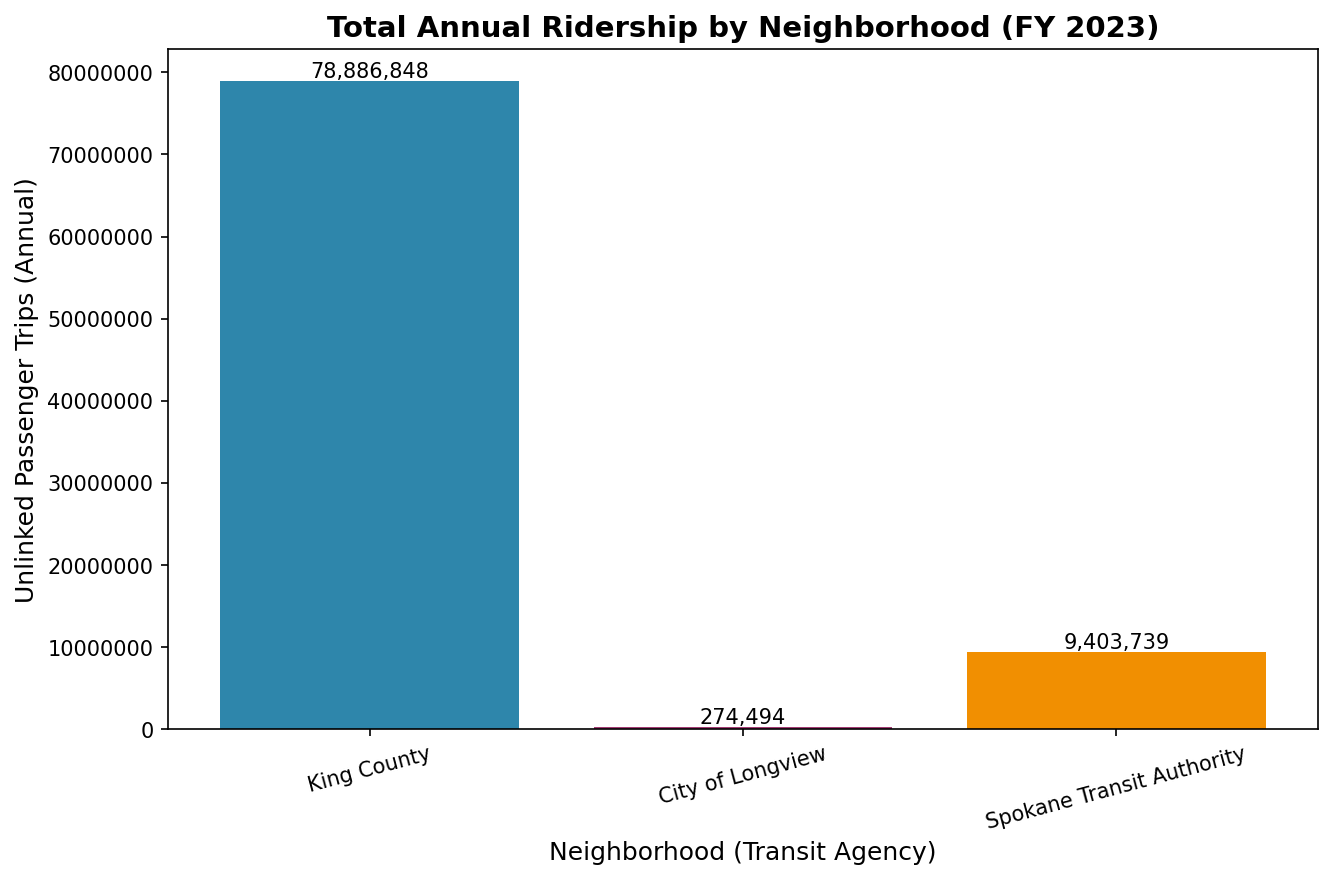

In [9]:
# Group the data by agency and sum ridership across every active mode of service.
# This gives one total-ridership value per neighborhood.
total_ridership = (
    nbh_df.groupby("Agency")["Unlinked Passenger Trips FY"]
          .sum()
          .reindex(neighborhoods)   # keep the agencies in the order defined above
)

# Create the bar chart.
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(total_ridership.index, total_ridership.values,
              color=["#2E86AB", "#A23B72", "#F18F01"])

# Annotate each bar with its numeric value so the exact ridership is easy to read.
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f"{height:,.0f}", ha="center", va="bottom", fontsize=10)

# Add a descriptive title and axis labels.
ax.set_title("Total Annual Ridership by Neighborhood (FY 2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("Neighborhood (Transit Agency)", fontsize=12)
ax.set_ylabel("Unlinked Passenger Trips (Annual)", fontsize=12)
ax.ticklabel_format(style="plain", axis="y")  # turn off scientific notation on the y-axis
plt.xticks(rotation=15)
plt.tight_layout()

# Save the figure as a PNG inside the output folder, then close it to free memory.
viz1_path = os.path.join(output_folder, "viz1_total_ridership.png")
plt.savefig(viz1_path, dpi=150, bbox_inches="tight")
plt.close()

# Re-render the saved image so it shows in the notebook and HTML export.
display(Image(filename=viz1_path))

### Visualization 2: Ridership Composition by Transit Mode
The first chart shows totals, but it hides *how* each neighborhood delivers its service. This grouped bar chart breaks each neighborhood's ridership down by **transit mode** (Bus, Ferry, Rail, etc.). It reveals whether a neighborhood relies on a single mode or operates a diversified system, which is directly relevant to the nonprofit's interest in transit access and equity.

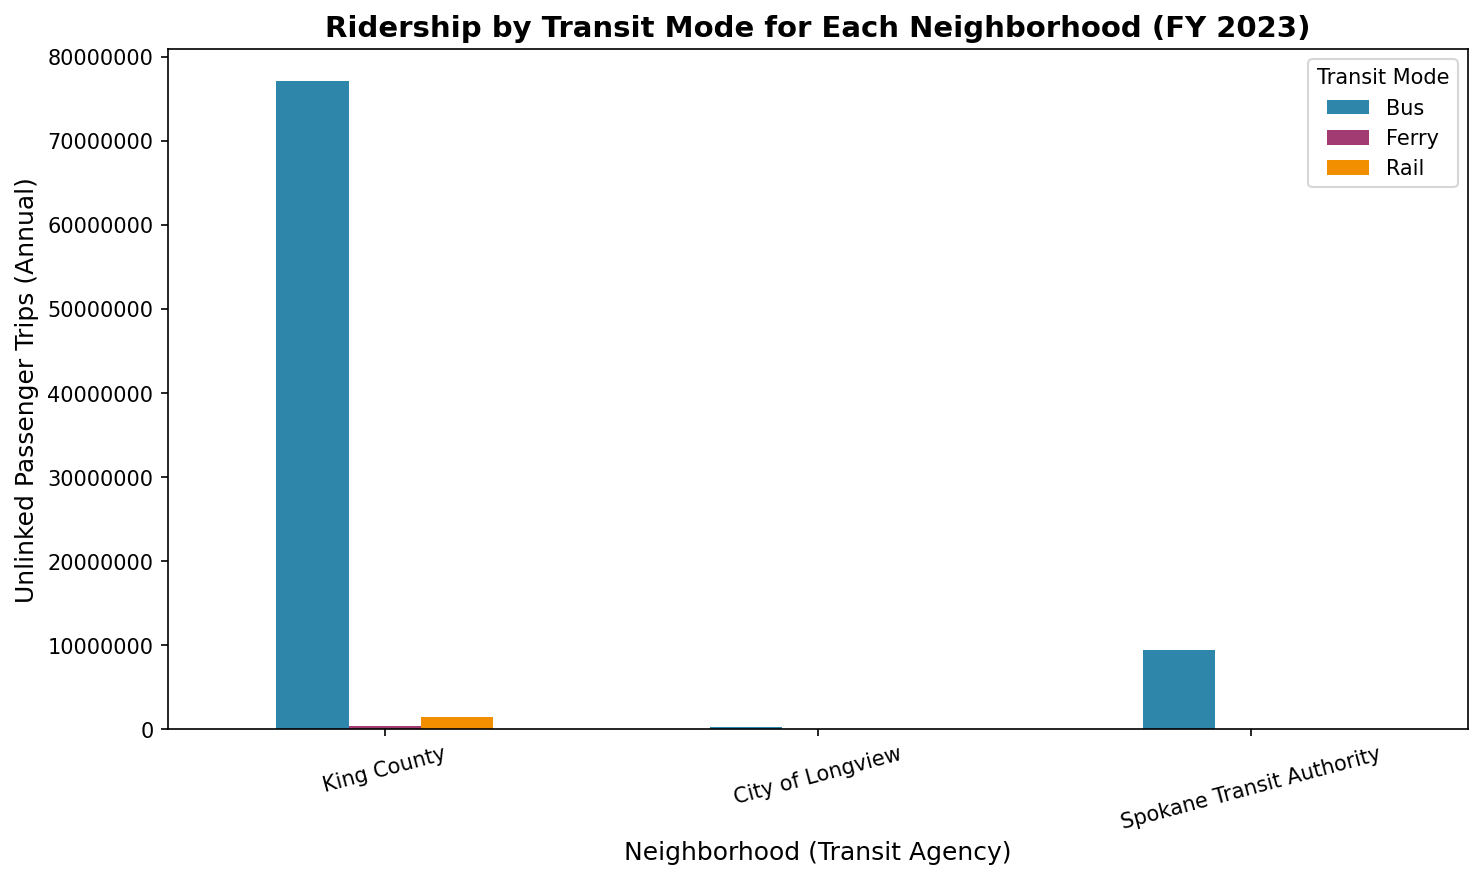

Ridership by Mode (Unlinked Passenger Trips, FY):
3 Mode                          Bus   Ferry     Rail
Agency                                              
King County                77075344  399687  1411817
City of Longview             274494       0        0
Spokane Transit Authority   9403739       0        0


In [10]:
# Group the data by both agency and transit mode and sum the ridership for each combination.
# unstack() pivots the "3 Mode" level into columns so each row is an agency and each column is a mode.
# fill_value=0 ensures agencies that don't operate a given mode appear as 0 rather than NaN.
mode_ridership = (
    nbh_df.groupby(["Agency", "3 Mode"])["Unlinked Passenger Trips FY"]
          .sum()
          .unstack(fill_value=0)
          .reindex(neighborhoods)
)

# Plot a grouped bar chart so each mode gets its own bar next to the others for the same agency.
ax = mode_ridership.plot(kind="bar", figsize=(10, 6),
                         color=["#2E86AB", "#A23B72", "#F18F01", "#6A994E"])

# Add a descriptive title, axis labels, and a legend identifying each transit mode.
ax.set_title("Ridership by Transit Mode for Each Neighborhood (FY 2023)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Neighborhood (Transit Agency)", fontsize=12)
ax.set_ylabel("Unlinked Passenger Trips (Annual)", fontsize=12)
ax.legend(title="Transit Mode")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=15)
plt.tight_layout()

# Save and display the figure for HTML export.
viz2_path = os.path.join(output_folder, "viz2_ridership_by_mode.png")
plt.savefig(viz2_path, dpi=150, bbox_inches="tight")
plt.close()

display(Image(filename=viz2_path))

# Also print the underlying table so the exact numbers are easy to reference in the report.
print("Ridership by Mode (Unlinked Passenger Trips, FY):")
print(mode_ridership.fillna(0).astype(int))

### Visualization 3: Per-Capita Ridership (Annual Trips per Resident)
Raw ridership totals are heavily influenced by population — a service area of 2.3 million people will almost always have higher absolute ridership than one with 70,000, regardless of how well the transit system performs. To make the comparison fair, this chart divides each neighborhood's total annual ridership by its **Service Area Population**, producing a per-capita "annual trips per resident" figure. This normalized metric is a much better measure of how *intensively* a community uses its transit, and it directly speaks to equity and utilization questions that matter to the nonprofit.

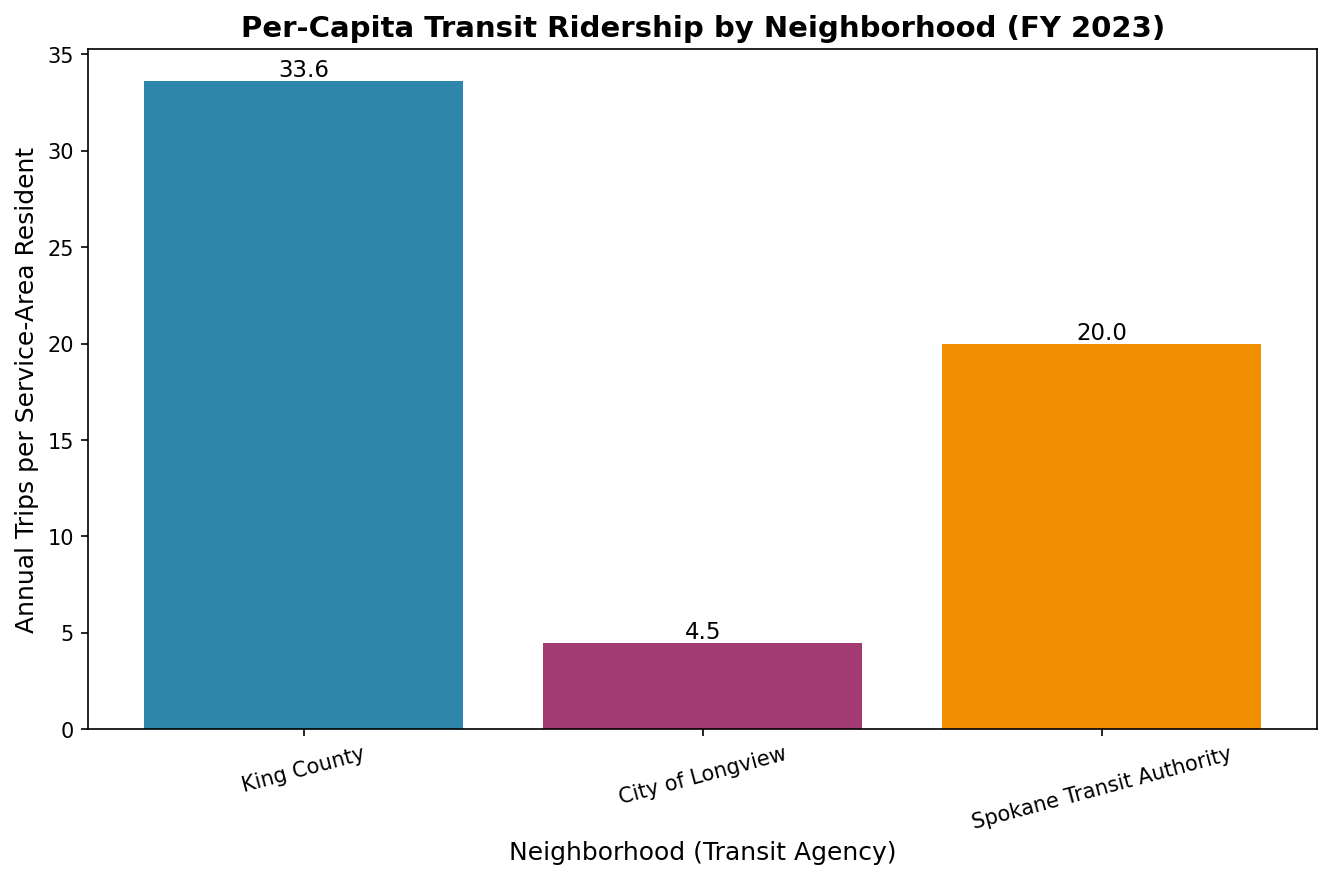

Per-Capita Ridership Summary:
                           total_trips  population  trips_per_resident
Agency                                                                
King County                   78886848   2347800.0               33.60
City of Longview                274494     61598.0                4.46
Spokane Transit Authority      9403739    471169.0               19.96


In [11]:
# Build a small summary table that contains total ridership and population for each neighborhood.
# We take the first (max) Service Area Population per agency because the value is the same across that
# agency's rows in the dataset.
per_capita = (
    nbh_df.groupby("Agency")
          .agg(total_trips=("Unlinked Passenger Trips FY", "sum"),
               population=("Service Area Population", "max"))
          .reindex(neighborhoods)
)

# Calculate annual transit trips per resident -- the headline equity metric.
per_capita["trips_per_resident"] = per_capita["total_trips"] / per_capita["population"]

# Plot the per-capita ridership as a bar chart so the three neighborhoods can be directly compared.
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(per_capita.index, per_capita["trips_per_resident"],
              color=["#2E86AB", "#A23B72", "#F18F01"])

# Annotate each bar with the per-capita value (rounded to one decimal) for quick interpretation.
for bar, value in zip(bars, per_capita["trips_per_resident"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.1f}", ha="center", va="bottom", fontsize=11)

# Add a descriptive title and axis labels.
ax.set_title("Per-Capita Transit Ridership by Neighborhood (FY 2023)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Neighborhood (Transit Agency)", fontsize=12)
ax.set_ylabel("Annual Trips per Service-Area Resident", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Save the figure and display it inline.
viz3_path = os.path.join(output_folder, "viz3_per_capita.png")
plt.savefig(viz3_path, dpi=150, bbox_inches="tight")
plt.close()

display(Image(filename=viz3_path))

# Print the underlying summary table for transparency in the report.
print("Per-Capita Ridership Summary:")
print(per_capita.round(2))